512


/root/miniconda3/envs/new/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


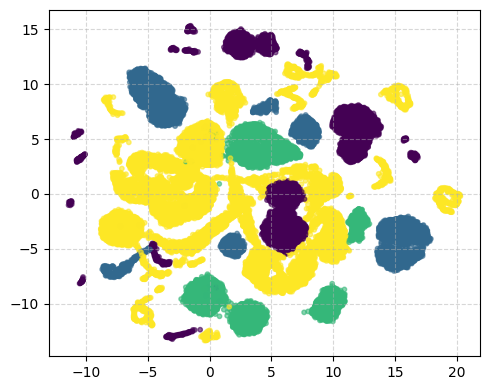

In [6]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP

HyperParameter = "out_channels"
test_domain = "331"
origin_domain_num = 4
encoder = 1
feature_ratio = 0.1
channels_size = int(1024/(2**encoder))
channels_num = 2
print(channels_size)

path = "/root/autodl-tmp/feature_map/"
feature = np.load(path + f"{HyperParameter}_{origin_domain_num}_{test_domain}_encoder_{encoder}.npy")
feature = feature[:int(feature.shape[0]*feature_ratio), :]
label = np.load(path + f"{HyperParameter}_{origin_domain_num}_{test_domain}_labels.npy")
label = label[:int(label.shape[0]*feature_ratio)]

X = feature
X = (X - X.min(axis=1, keepdims=True)) / (X.max(axis=1, keepdims=True) - X.min(axis=1, keepdims=True))
Y = label
# X_pca = PCA(n_components=64).fit_transform(X)

# # 使用 t-SNE
# X_tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1).fit_transform(X_pca)

def plot_multiple_umaps(X, Y, n_list, md):
    plt.figure(figsize=(len(n_list) * 5, 4))
    for idx, n in enumerate(n_list, 1):
        # umap = UMAP(n_components=2, n_neighbors=n, min_dist=1,target_metric='categorical', n_jobs=4)
        umap = UMAP(n_components=2, n_neighbors=n, min_dist=md, n_jobs=4)
        X_umap = umap.fit_transform(X)

        plt.subplot(1, len(n_list), idx)
        scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=Y, cmap='viridis', alpha=0.6, s=10)
        # plt.title(f'UMAP n_neighbors={n}')
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_multiple_umaps(X, Y, [10], 0.6)


512
44234


/root/miniconda3/envs/new/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


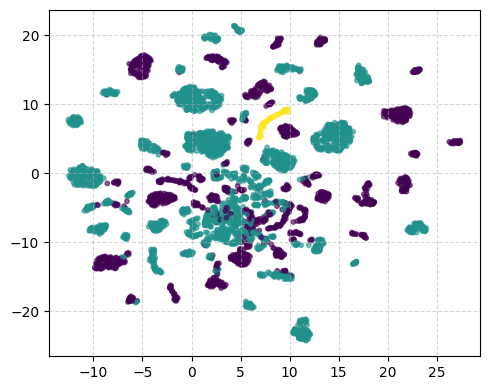

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP

HyperParameter = "kernel_size"
test_domain = "331"
origin_domain_num = 4
encoder = 1
feature_ratio = 0.1
channels_size = int(1024/(2**encoder))
channels_num = 2
print(channels_size)

path = "/root/autodl-tmp/feature_map/"
feature = np.load(path + f"{HyperParameter}_{origin_domain_num}_{test_domain}_encoder_{encoder}.npy")
label = np.load(path + f"{HyperParameter}_{origin_domain_num}_{test_domain}_labels.npy")
# 样本数量
num_samples = feature.shape[0]
select_num = int(num_samples * feature_ratio)

# 随机选择索引（不放回）
selected_indices = np.random.choice(num_samples, size=select_num, replace=False)

# 应用到特征和标签
feature = feature[selected_indices, :channels_size*channels_num]
label = label[selected_indices]

print(label.shape[0])

num_samples = feature.shape[0]
select_num = int(num_samples * feature_ratio)
selected_indices = np.random.choice(num_samples, size=select_num, replace=False)
feature = feature[selected_indices]
label = label[selected_indices]

X = feature
X = (X - X.min(axis=1, keepdims=True)) / (X.max(axis=1, keepdims=True) - X.min(axis=1, keepdims=True))
Y = label

def plot_multiple_umaps(X, Y, n_list, md):
    plt.figure(figsize=(len(n_list) * 5, 4))
    for idx, n in enumerate(n_list, 1):
        # umap = UMAP(n_components=2, n_neighbors=n, min_dist=1, target_metric='categorical', n_jobs=4)
        umap = UMAP(n_components=2, n_neighbors=n, min_dist=md, n_jobs=4)
        X_umap = umap.fit_transform(X)

        plt.subplot(1, len(n_list), idx)
        scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=Y, cmap='viridis', alpha=0.6, s=10)
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_multiple_umaps(X, Y, [15], 0.8)
